In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print("Using device :", device )

# LSTM cell 

class LSTMCellScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear (input_size + hidden_size , 4 * hidden_size)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([h_prev, x], dim=1)            # ( 2 , 30 )
        gates = self.W(combined)
        
        f, i, g, o = gates.chunk(4, dim=1)
        f = torch.sigmoid(f)    # Forget gate
        i = torch.sigmoid(i)    # Input gate
        g = torch.tanh(g)       # Candidate values
        o = torch.sigmoid(o)    # Output gate

        c_next = f * c_prev + i * g 
        h_next = o * torch.tanh(c_next) 

        return h_next, c_next

batch_size, input_size, hidden_size = 2, 10, 20

lstm_cell = LSTMCellScratch(input_size, hidden_size).to(device)

x = torch.randn(batch_size, input_size).to(device)
h = torch.zeros(batch_size, hidden_size).to(device)
c = torch.zeros(batch_size, hidden_size).to(device)

h_new, c_new = lstm_cell(x, h, c)
print(f"\nLSTM Cell Test:")
print(f"  Input shape:       {x.shape}")
print(f"  Hidden state out:  {h_new.shape}")
print(f"  Cell state out:    {c_new.shape}")



Using device : mps

LSTM Cell Test:
  Input shape:       torch.Size([2, 10])
  Hidden state out:  torch.Size([2, 20])
  Cell state out:    torch.Size([2, 20])


In [3]:
class GRUCellScratch(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size 

        self.W_rz = nn.Linear(input_size + hidden_size , 2 * hidden_size)
        self.W_n = nn.Linear(input_size + hidden_size , hidden_size)
    
    def forward(self, x, h_prev):
        combined = torch.cat([h_prev, x], dim=1)
        rz = self.W_rz(combined)
        r, z = rz.chunk(2, dim=1)

        r = torch.sigmoid(r)
        z = torch.sigmoid(z)

        combined_r = torch.cat([r * h_prev, x ], dim = 1)           # How muxh of the prev output to be exposed
        n = torch.tanh(self.W_n(combined_r))
        
        h_next = (1 - z) * h_prev + z * n 

        return h_next 


gru_cell = GRUCellScratch(input_size, hidden_size).to(device)
h_gru = torch.zeros(batch_size, hidden_size).to(device)
h_gru_new = gru_cell(x, h_gru)
print(f"\nGRU Cell Test:")
print(f"  Input shape:       {x.shape}")
print(f"  Hidden state out:  {h_gru_new.shape}")


GRU Cell Test:
  Input shape:       torch.Size([2, 10])
  Hidden state out:  torch.Size([2, 20])


In [10]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,                               # (batch, seq, features)
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, (h_n, c_n) = self.lstm(x)

        # Use last timestep's output for classification
        out = self.fc(out[:, -1, :])
        return out

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, h_n = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

seq_len = 50 
lstm_model = LSTMModel(input_size = 1, hidden_size = 32, num_layers = 2, output_size = 1).to(device)
gru_model  = GRUModel(input_size=1, hidden_size=32, num_layers=2, output_size=1).to(device)

dummy = torch.randn(batch_size, seq_len, 1).to(device)
print(f"\nFull Model Shape Test:")
print(f"  Input:       {dummy.shape}")
print(f"  LSTM output: {lstm_model(dummy).shape}")
print(f"  GRU output:  {gru_model(dummy).shape}")



Full Model Shape Test:
  Input:       torch.Size([2, 50, 1])
  LSTM output: torch.Size([2, 1])
  GRU output:  torch.Size([2, 1])


In [19]:
def make_sine_data(n_samples=1000, seq_len=50):
    """Generate sine wave sequences for next-step prediction."""
    t = np.linspace(0, 20 * np.pi, n_samples + seq_len)
    data = np.sin(t).astype(np.float32)

    X, y = [], []
    for i in range(n_samples):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])

    X = torch.tensor(np.array(X)).unsqueeze(-1)  # (n, seq, 1)
    y = torch.tensor(np.array(y)).unsqueeze(-1)  # (n, 1)
    return X, y


X, y = make_sine_data()
indices = torch.randperm(len(X))
X, y = X[indices], y[indices]
split = int(0.8 * len(X))
X_train, X_test = X[:split].to(device), X[split:].to(device)
y_train, y_test = y[:split].to(device), y[split:].to(device)

print(f"\nSine Wave Dataset:")
print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Test:  X={X_test.shape},  y={y_test.shape}")

def train_model(model, X_train, y_train, epochs=50, lr=0.0005, batch_size=32):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses = []

    model.train()
    for epoch in range(epochs):
        # Mini-batch training
        permutation = torch.randperm(X_train.size(0))
        epoch_loss = 0.0
        n_batches = 0

        for i in range(0, X_train.size(0), batch_size):
            idx = permutation[i:i+batch_size]
            X_batch, y_batch = X_train[idx], y_train[idx]

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.6f}")

    return losses

print("\nTraining LSTM...")
torch.manual_seed(42)
lstm_model = LSTMModel(1, 32, 1, 1).to(device)
lstm_losses = train_model(lstm_model, X_train, y_train, epochs=50)

print("\nTraining GRU...")
gru_model = GRUModel(1, 32, 2, 1).to(device)
gru_losses = train_model(gru_model, X_train, y_train, epochs=50)


Sine Wave Dataset:
  Train: X=torch.Size([800, 50, 1]), y=torch.Size([800, 1])
  Test:  X=torch.Size([200, 50, 1]),  y=torch.Size([200, 1])

Training LSTM...
  Epoch 05/50 | Loss: 0.049558
  Epoch 10/50 | Loss: 0.000146
  Epoch 15/50 | Loss: 0.000075
  Epoch 20/50 | Loss: 0.000048
  Epoch 25/50 | Loss: 0.000029
  Epoch 30/50 | Loss: 0.000020
  Epoch 35/50 | Loss: 0.000016
  Epoch 40/50 | Loss: 0.000013
  Epoch 45/50 | Loss: 0.000014
  Epoch 50/50 | Loss: 0.000008

Training GRU...
  Epoch 05/50 | Loss: 0.023729
  Epoch 10/50 | Loss: 0.006740
  Epoch 15/50 | Loss: 0.002289
  Epoch 20/50 | Loss: 0.002232
  Epoch 25/50 | Loss: 0.001840
  Epoch 30/50 | Loss: 0.001419
  Epoch 35/50 | Loss: 0.001234
  Epoch 40/50 | Loss: 0.001150
  Epoch 45/50 | Loss: 0.001058
  Epoch 50/50 | Loss: 0.000938


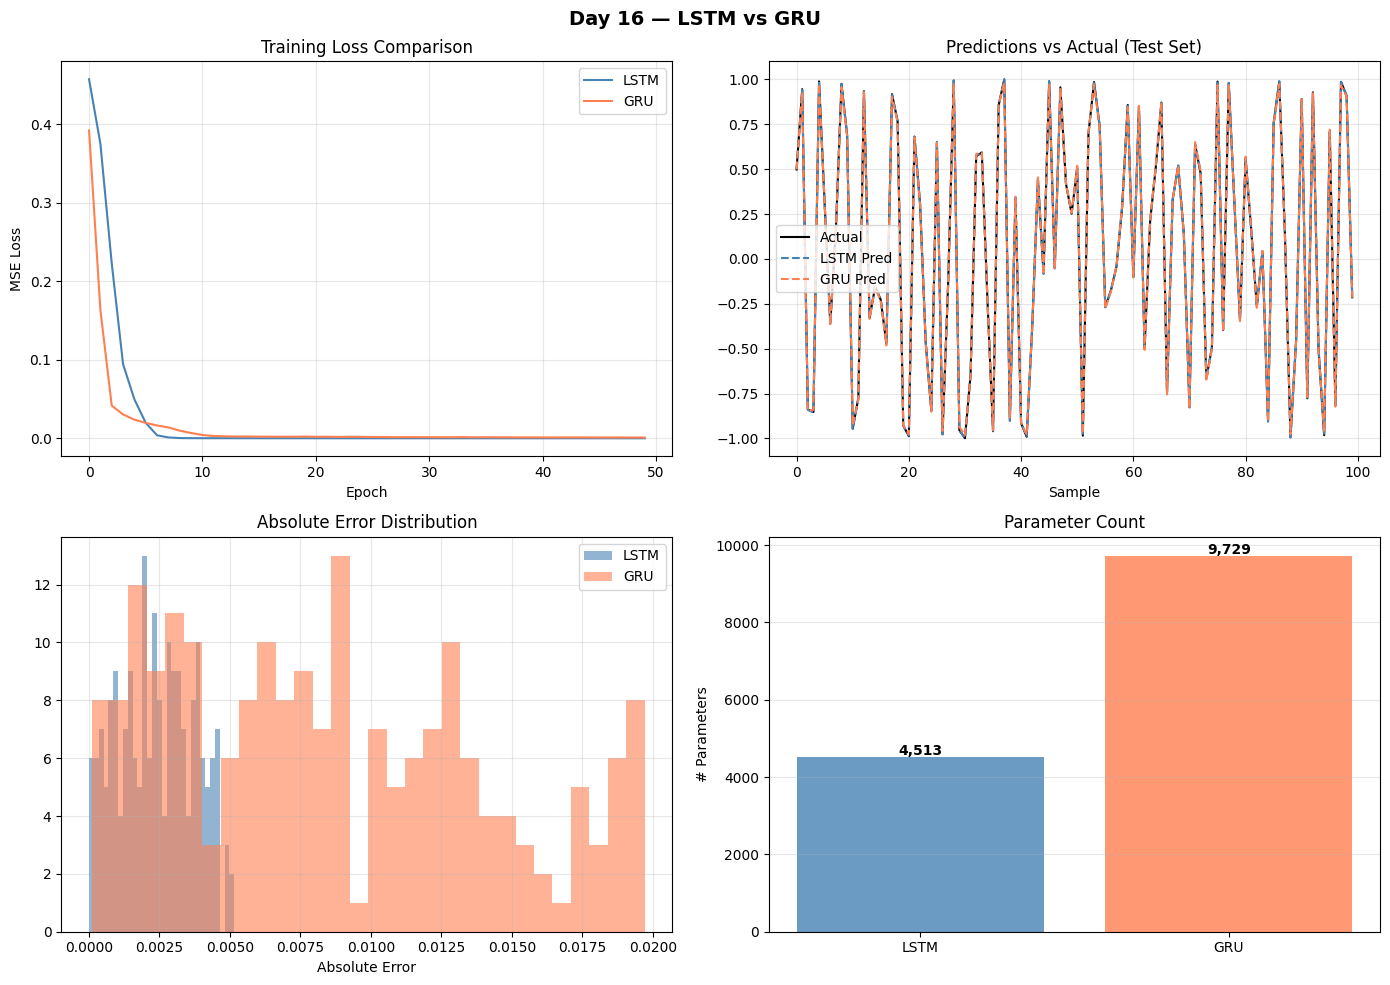


Final Test MSE:
  LSTM: 0.000008
  GRU:  0.000102
  GRU params: 9,729 vs LSTM params: 4,513


In [20]:
lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_preds = lstm_model(X_test).cpu().numpy()
    gru_preds  = gru_model(X_test).cpu().numpy()
    actuals    = y_test.cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Day 16 — LSTM vs GRU', fontsize=14, fontweight='bold')

# Plot 1: Training loss comparison
axes[0, 0].plot(lstm_losses, label='LSTM', color='steelblue')
axes[0, 0].plot(gru_losses,  label='GRU',  color='coral')
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Predictions vs actual (first 100 test samples)
n = 100
axes[0, 1].plot(actuals[:n],    label='Actual',    color='black', linewidth=1.5)
axes[0, 1].plot(lstm_preds[:n], label='LSTM Pred', color='steelblue', linestyle='--')
axes[0, 1].plot(gru_preds[:n],  label='GRU Pred',  color='coral', linestyle='--')
axes[0, 1].set_title('Predictions vs Actual (Test Set)')
axes[0, 1].set_xlabel('Sample')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: LSTM error distribution
lstm_errors = np.abs(lstm_preds - actuals).flatten()
gru_errors  = np.abs(gru_preds  - actuals).flatten()
axes[1, 0].hist(lstm_errors, bins=30, alpha=0.6, label='LSTM', color='steelblue')
axes[1, 0].hist(gru_errors,  bins=30, alpha=0.6, label='GRU',  color='coral')
axes[1, 0].set_title('Absolute Error Distribution')
axes[1, 0].set_xlabel('Absolute Error')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Parameter count comparison
lstm_params = sum(p.numel() for p in lstm_model.parameters())
gru_params  = sum(p.numel() for p in gru_model.parameters())
axes[1, 1].bar(['LSTM', 'GRU'], [lstm_params, gru_params],
               color=['steelblue', 'coral'], alpha=0.8)
axes[1, 1].set_title('Parameter Count')
axes[1, 1].set_ylabel('# Parameters')
for i, v in enumerate([lstm_params, gru_params]):
    axes[1, 1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('day16_lstm_gru.png', dpi=150, bbox_inches='tight')
plt.show()

# Final metrics
lstm_mse = np.mean((lstm_preds - actuals)**2)
gru_mse  = np.mean((gru_preds  - actuals)**2)
print(f"\nFinal Test MSE:")
print(f"  LSTM: {lstm_mse:.6f}")
print(f"  GRU:  {gru_mse:.6f}")
print(f"  GRU params: {gru_params:,} vs LSTM params: {lstm_params:,}")
